# Notebook 8 — Inverse-Game Diagnosis under Scarce Experimental Budgets
## GPT-5.2 hidden-mechanism design vs. GPT-4o-mini active structural inference

### Introduction

The preceding version of Notebook 8 established an important methodological transition. Notebook 7 asked whether an observer could recognize a strategically familiar game after its representation had been deliberately transformed. Notebook 8 removed the payoff matrix entirely and asked a more difficult question: could an observer infer the latent strategic mechanism from behavior by choosing interventions? That change moved the experiment from recognition toward inverse inference. It also exposed several limitations that are scientifically useful rather than merely technical.

The executed experiment showed that the previous design was still too compressed. Five possible probes were available and the adaptive observer could choose four of them. In effect, the observer was allowed to inspect eighty percent of the entire intervention space. Under those conditions, adaptive probe selection had little room to create value relative to a fixed schedule. The previous notebook also asked the model to provide a free-form family label even though the task was explicitly described as open set. The evaluator then attempted to map that prose back into five private canonical labels. This created a scoring mismatch: a potentially useful structural explanation could be counted as completely wrong because it did not reproduce the notebook's internal taxonomy. Finally, each intervention was observed only through a very small number of Bernoulli trials. Sampling noise could therefore be larger than the strategic effect the observer was expected to infer.

This notebook is designed around those lessons.

The central question is no longer simply whether GPT-4o mini can attach the correct canonical name to a hidden game. The stronger question is whether a bounded observer can **discover enough of the hidden causal-strategic mechanism to make accurate predictions about interventions it has never observed**, while deciding how to spend a scarce experimental budget. The notebook therefore separates three different objects of inference that were previously conflated.

The first is **closed-set diagnosis**. For benchmarking purposes, the observer is told that the hidden case belongs to one of five canonical mechanism families—short-horizon Prisoner's Dilemma, repeated Prisoner's Dilemma, Stag/Assurance, Coordination, or Common Cause—with an additional `Other/Hybrid` escape category. Instead of returning a single label and an arbitrary confidence number, the observer must return a complete probability distribution across these six possibilities. This makes uncertainty measurable. The notebook can calculate top-one accuracy, multiclass Brier score, log loss, posterior entropy, and calibration-oriented diagnostics without depending on fuzzy text normalization.

The second is **open-set mechanism reconstruction**. Canonical labels are useful for benchmarking, but they are not the deepest scientific target. The hidden environment is generated from a latent parameter vector describing the importance of future interaction, communication, direct payoff incentives, partner dependence, common signals, and coordination thresholds. GPT-4o mini must estimate those latent dimensions directly and summarize the mechanism in ordinary language. This allows the experiment to ask whether the observer has learned something structurally meaningful even when its canonical family classification is imperfect.

The third is **counterfactual prediction**. Every hidden case reserves three interventions that neither adaptive nor passive observers are allowed to execute. Both arms must predict the target-event probability under those same three held-out interventions. Because the held-out set is common across arms, the comparison is paired and directly interpretable. One held-out intervention is chosen from a region where the hidden mechanism and its deliberately constructed decoy are very similar, one from an intermediate region, and one from a highly discriminating region. The resulting test asks whether the observer has learned the shape of the mechanism rather than memorized the interventions it happened to see.

The intervention space is expanded from five probes to twelve. Several intervention pairs vary the same strategic dimension at different intensities: removing the future versus merely reducing continuation probability; removing communication versus adding noise; increasing the target payoff versus reducing unilateral temptation; revealing a common signal versus degrading it; and changing coordination thresholds or information symmetry. The observer is not permitted to inspect most of these probes. It receives a total experimental budget of thirty-two synthetic trials and at most four decision rounds. At each round, it chooses both **which probe to run** and **how many trials to allocate**—four, eight, or twelve—subject to the remaining budget. Repeating a previously used probe is allowed. This turns adaptive experimentation into a genuine resource-allocation problem.

The hidden cases are also harder. GPT-5.2 remains the private mechanism designer, but it no longer proposes a table of unrelated probabilities. It proposes a latent parameter vector and a neutral public scenario. Deterministic Python code then projects the proposal into the admissible geometry of the source family and performs an adversarial refinement step. The refinement searches for a point that remains valid for the source family while looking deceptively similar to a second, private **decoy family** on several interventions and sharply different on others. The resulting case is intentionally constructed as a diagnostic trap: ordinary observations should support multiple explanations, while a small number of well-chosen experiments should be much more informative.

The environment itself is generated from a transparent response function. A baseline target-event probability is transformed by the six latent mechanism parameters and the feature vector associated with each intervention. Python—not either LLM—executes all stochastic observations. The same hidden mechanism and the same deterministic random streams are used across experimental arms. When adaptive and passive conditions happen to run the same probe with the same number of trials, they therefore see matched evidence rather than unrelated samples.

Three experimental comparators are retained. The principal contrast is GPT-4o-mini adaptive probing versus a balanced passive schedule fixed before outcomes are observed. A Bayesian expected-information-gain benchmark is added as a non-LLM reference point. It knows only the five canonical prototype mechanisms, not the actual GPT-5.2 hidden parameter vector. Its purpose is not to establish an unattainable omniscient standard, but to ask how close the LLM's experimental choices come to a transparent information-theoretic strategy.

The notebook remains deliberately safe and synthetic. No external systems are probed. No real agents are manipulated. The interventions alter only an in-memory stochastic mechanism. The scientific ambition is narrower and more defensible: to study whether language-model reasoning can support active experimental design under uncertainty, and whether the resulting structural model generalizes beyond the evidence used to construct it.

The most important conceptual shift is therefore this:

$
\boxed{
\text{Do not ask only: ``What game is this?''}
}
$

Instead ask:

$
\boxed{
\text{What hidden mechanism best explains the observations,}
\quad
\text{which experiment should be run next,}
\quad
\text{and what should happen in environments never observed?}
}
$

That is the inverse-game problem this notebook is designed to explore.

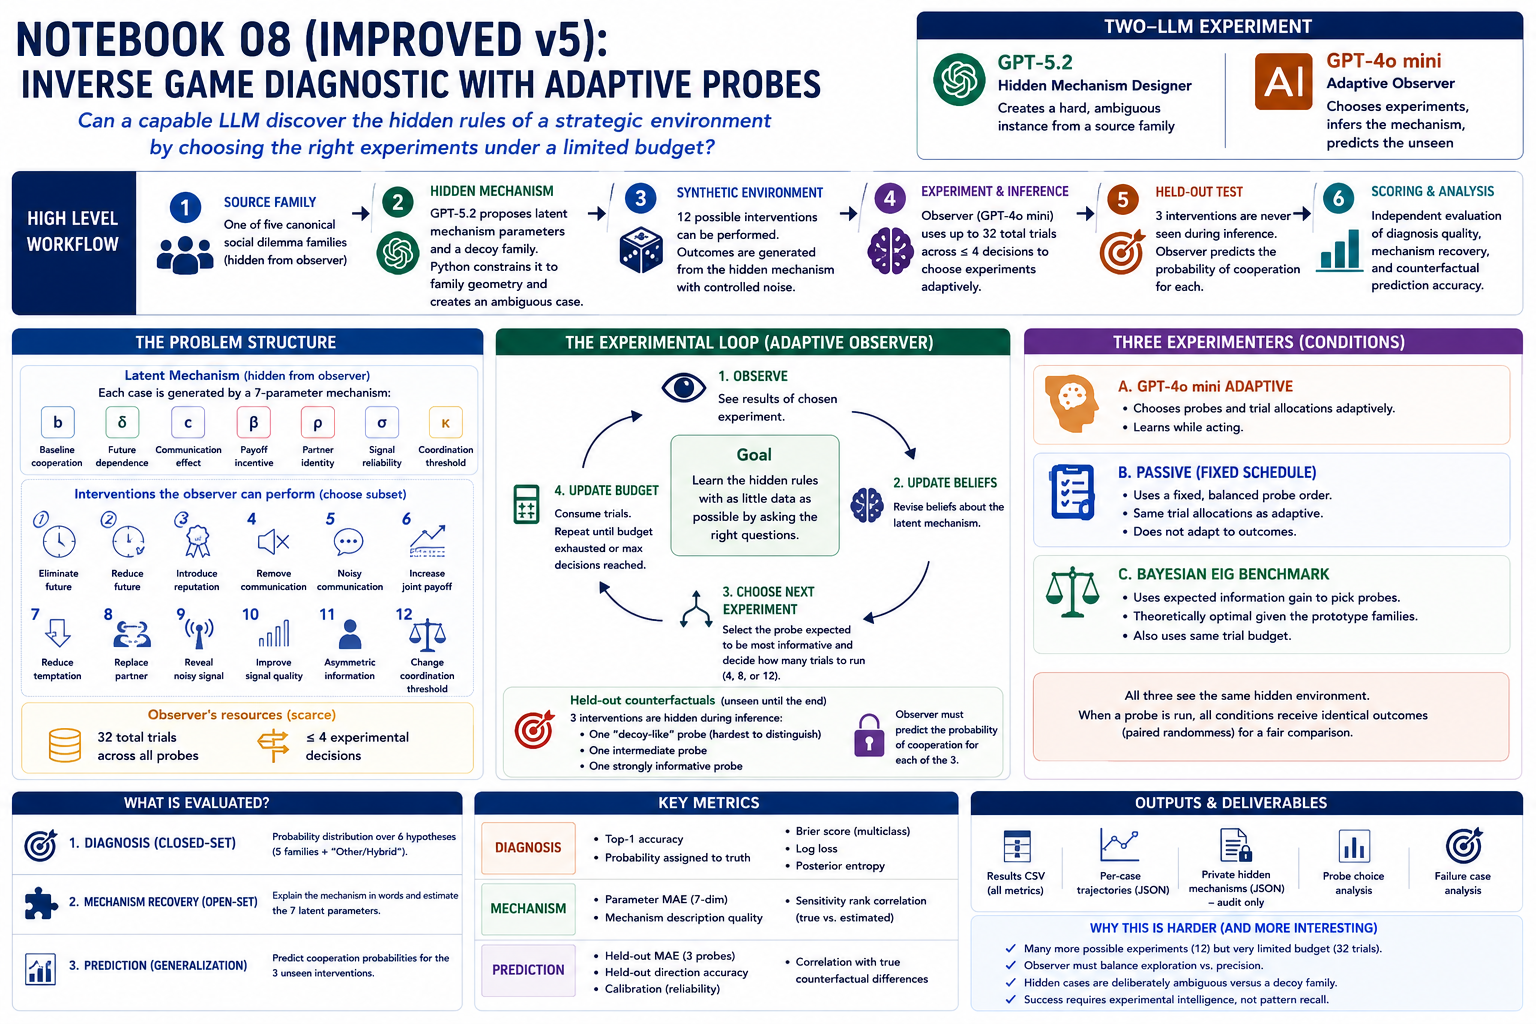

## Research question, hypotheses, and evidentiary boundary

**Primary research question.** Can GPT-4o mini recover a useful latent strategic mechanism and predict unseen interventions more accurately when it adaptively chooses experiments under a scarce evidence budget than when it receives a fixed passive probe schedule?

**Secondary question.** How close does LLM-selected experimentation come to a transparent Bayesian expected-information-gain benchmark?

**Primary null hypothesis.**

$
H_0:
\quad
\text{Adaptive probe choice provides no improvement over passive probing}
$

in family discrimination, latent-parameter recovery, or common held-out counterfactual prediction.

**Scientific status.** This is a safe synthetic laboratory. It evaluates only the models, prompts, parameters, grammar, probes, budgets, and seeds specified here. It does not establish universal properties of LLMs, autonomous agents, humans, deliberate concealment, deception, consciousness, or real-world strategic systems.

## Experimental architecture

$
\boxed{
\text{Source family}
\rightarrow
\text{GPT-5.2 latent proposal}
\rightarrow
\text{Python projection + ambiguity refinement}
\rightarrow
\text{synthetic environment}
\rightarrow
\begin{cases}
\text{GPT-4o-mini adaptive}\\
\text{fixed passive}\\
\text{Bayesian EIG benchmark}
\end{cases}
\rightarrow
\text{common held-out counterfactuals}
}
$

The decisive design principle is the same as in Notebook 7: **the model that creates difficulty does not certify its own construction, and the model being evaluated does not receive the hidden certificate.**

In [2]:
%pip -q install -U openai pandas numpy matplotlib


In [3]:
import json, math, random, re, time, platform, sys, hashlib, copy
from typing import Any, Dict, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openai
from openai import OpenAI

SEED = 762
random.seed(SEED)
rng = np.random.default_rng(SEED)

MANIFEST = {
    "seed": SEED,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "mode": "safe_synthetic_inverse_game_v5",
}
print(json.dumps(MANIFEST, indent=2))


{
  "seed": 762,
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "mode": "safe_synthetic_inverse_game_v5"
}


## Load the OpenAI API key from Colab Secrets

The notebook uses one secret:

- `OPENAI_API_KEY`

The key is never printed.

In [4]:
from google.colab import userdata

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise RuntimeError("OPENAI_API_KEY was not found in Colab Secrets.")

openai_client = OpenAI(api_key=OPENAI_API_KEY)
print("OpenAI client initialized from Colab Secrets.")


OpenAI client initialized from Colab Secrets.


In [5]:
print("openai SDK:", getattr(openai, "__version__", "unknown"))


openai SDK: 3.6.0


## Configuration

`gpt-5.2` privately proposes the hidden mechanism and public scenario. `gpt-4o-mini` is the experimental observer.

The defaults create ten hidden cases: two replications for each of five source families. Increase `N_REPS_PER_FAMILY` only after the notebook runs reliably because GPT-5.2 is the expensive component.

In [6]:
DESIGNER_MODEL = "gpt-5.2"
OBSERVER_MODEL = "gpt-4o-mini"

DESIGNER_REASONING_EFFORT = "high"
DESIGNER_REASONING_FALLBACK = "medium"
DESIGNER_MAX_OUTPUT_TOKENS = 4500
OBSERVER_MAX_OUTPUT_TOKENS = 1800
MAX_MODEL_RETRIES = 3

N_REPS_PER_FAMILY = 2

BASELINE_TRIALS = 12
TOTAL_EXPERIMENTAL_BUDGET = 32
MAX_ADAPTIVE_ROUNDS = 4
ALLOWED_BATCH_SIZES = [4, 8, 12]

PASSIVE_BATCH_SIZE = 8
PASSIVE_ROUNDS = 4

N_HELDOUT_PROBES = 3
AMBIGUITY_SEARCH_DRAWS = 2500

RUN_PASSIVE_CONTROL = True
RUN_EIG_BENCHMARK = True
SLEEP_BETWEEN_CASES = 0.15

print({
    "designer": DESIGNER_MODEL,
    "observer": OBSERVER_MODEL,
    "cases": 5 * N_REPS_PER_FAMILY,
    "adaptive_budget": TOTAL_EXPERIMENTAL_BUDGET,
    "adaptive_rounds": MAX_ADAPTIVE_ROUNDS,
})


{'designer': 'gpt-5.2', 'observer': 'gpt-4o-mini', 'cases': 10, 'adaptive_budget': 32, 'adaptive_rounds': 4}


## The latent mechanism

Instead of defining each game as a table of unrelated intervention probabilities, each hidden case has the latent parameter vector

$
\theta =
(b,\delta,c,\beta,\rho,\sigma,\kappa),
$

where:

- \(b\) is the baseline target-event probability;
- \(\delta\) is future-interaction dependence;
- \(c\) is communication dependence;
- \(\beta\) is direct payoff sensitivity;
- \(\rho\) is partner/relationship dependence;
- \(\sigma\) is common-signal dependence;
- \(\kappa\) is coordination-threshold sensitivity.

The five source families constrain these parameters to different broad regions. These are deliberately overlapping regions rather than isolated textbook points.

In [7]:
FAMILIES = ["PD_short", "PD_repeated", "Stag", "Coordination", "CommonCause"]
THETA_KEYS = ["future", "communication", "payoff", "partner", "signal", "coordination"]
ALL_CLASSES = FAMILIES + ["Other_Hybrid"]

FAMILY_THETA_RANGES = {
    "PD_short": {
        "base_rate": (0.12, 0.35),
        "future": (0.05, 0.25),
        "communication": (0.05, 0.28),
        "payoff": (0.55, 0.95),
        "partner": (0.05, 0.28),
        "signal": (0.05, 0.28),
        "coordination": (0.05, 0.32),
    },
    "PD_repeated": {
        "base_rate": (0.28, 0.55),
        "future": (0.62, 0.95),
        "communication": (0.15, 0.48),
        "payoff": (0.35, 0.78),
        "partner": (0.25, 0.62),
        "signal": (0.05, 0.32),
        "coordination": (0.10, 0.38),
    },
    "Stag": {
        "base_rate": (0.42, 0.70),
        "future": (0.15, 0.48),
        "communication": (0.52, 0.92),
        "payoff": (0.18, 0.58),
        "partner": (0.42, 0.82),
        "signal": (0.15, 0.50),
        "coordination": (0.58, 0.96),
    },
    "Coordination": {
        "base_rate": (0.40, 0.68),
        "future": (0.05, 0.32),
        "communication": (0.60, 0.96),
        "payoff": (0.12, 0.48),
        "partner": (0.05, 0.38),
        "signal": (0.20, 0.58),
        "coordination": (0.68, 0.98),
    },
    "CommonCause": {
        "base_rate": (0.35, 0.68),
        "future": (0.05, 0.30),
        "communication": (0.05, 0.32),
        "payoff": (0.05, 0.38),
        "partner": (0.05, 0.32),
        "signal": (0.72, 0.98),
        "coordination": (0.10, 0.48),
    },
}

def midpoint(lo_hi):
    lo, hi = lo_hi
    return (lo + hi) / 2

FAMILY_CENTERS = {
    f: {k: midpoint(v) for k, v in spec.items()}
    for f, spec in FAMILY_THETA_RANGES.items()
}

display(pd.DataFrame(FAMILY_CENTERS).T.round(3))


,base_rate,future,communication,payoff,partner,signal,coordination
PD_short,0.235,0.150,0.165,0.750,0.165,0.165,0.185
PD_repeated,0.415,0.785,0.315,0.565,0.435,0.185,0.240
Stag,0.560,0.315,0.720,0.380,0.620,0.325,0.770
Coordination,0.540,0.185,0.780,0.300,0.215,0.390,0.830
CommonCause,0.515,0.175,0.185,0.215,0.185,0.850,0.290


## Twelve interventions

The previous notebook had only five probes and allowed the observer to see four. Here there are twelve possible interventions. Several probe pairs perturb the same latent dimension at different intensities, making it possible to distinguish a real structural understanding from one-shot pattern matching.

In [8]:
PROBE_FEATURES = {
    "remove_future": {"future": -1.00},
    "reduce_continuation": {"future": -0.45},
    "add_reputation": {"future": +0.70},

    "remove_communication": {"communication": -1.00},
    "noisy_communication": {"communication": -0.50},

    "raise_target_payoff": {"payoff": +1.00},
    "reduce_temptation": {"payoff": +0.65},

    "replace_partner": {"partner": -1.00},

    "reveal_common_signal": {"signal": +1.00},
    "degrade_signal": {"signal": -0.70},

    "asymmetric_information": {
        "signal": -0.40,
        "communication": -0.20,
        "coordination": -0.25,
    },

    "lower_coordination_threshold": {"coordination": +0.90},
}

PROBE_DESCRIPTIONS = {
    "remove_future": "Make the interaction explicitly one-shot with no continuation.",
    "reduce_continuation": "Reduce, but do not eliminate, the probability of future interaction.",
    "add_reputation": "Introduce a public reputation record that can affect future matching.",
    "remove_communication": "Disable all pre-action communication.",
    "noisy_communication": "Allow communication, but randomly corrupt part of each message.",
    "raise_target_payoff": "Increase the payoff attached to the target joint outcome.",
    "reduce_temptation": "Reduce the unilateral reward from deviating from the target joint outcome.",
    "replace_partner": "Replace the current counterpart with a new anonymous actor.",
    "reveal_common_signal": "Reveal the same reliable external signal to both actors.",
    "degrade_signal": "Make the shared external signal substantially less reliable.",
    "asymmetric_information": "Give one actor materially better information than the other.",
    "lower_coordination_threshold": "Make successful joint coordination require less mutual assurance.",
}

PROBES = list(PROBE_FEATURES)
assert len(PROBES) == 12
display(pd.DataFrame({
    "probe": PROBES,
    "description": [PROBE_DESCRIPTIONS[p] for p in PROBES],
}))


,probe,description
0,remove_future,Make the interaction explicitly one-shot with ...
1,reduce_continuation,"Reduce, but do not eliminate, the probability ..."
2,add_reputation,Introduce a public reputation record that can ...
3,remove_communication,Disable all pre-action communication.
4,noisy_communication,"Allow communication, but randomly corrupt part..."
5,raise_target_payoff,Increase the payoff attached to the target joi...
6,reduce_temptation,Reduce the unilateral reward from deviating fr...
7,replace_partner,Replace the current counterpart with a new ano...
8,reveal_common_signal,Reveal the same reliable external signal to bo...
9,degrade_signal,Make the shared external signal substantially ...


## Transparent synthetic response function

The hidden environment converts the latent mechanism into an intervention probability through a logistic response model. This keeps the causal grammar inspectable:

$
p_a =
\operatorname{logit}^{-1}
\left[
\operatorname{logit}(b)
+
\lambda\sum_j x_{aj}\theta_j
\right].
$

The LLMs do not execute this function. Python does.

In [9]:
RESPONSE_SCALE = 1.35

def logit(p):
    p = min(1 - 1e-9, max(1e-9, float(p)))
    return math.log(p / (1 - p))

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def mechanism_probability(theta, probe=None):
    b = float(theta["base_rate"])
    if probe is None:
        return b
    shift = 0.0
    for k, coeff in PROBE_FEATURES[probe].items():
        shift += coeff * float(theta[k])
    return float(sigmoid(logit(b) + RESPONSE_SCALE * shift))

def probability_profile(theta):
    return {"baseline": mechanism_probability(theta, None),
            **{p: mechanism_probability(theta, p) for p in PROBES}}

PROTOTYPE_PROFILES = {
    f: probability_profile(center)
    for f, center in FAMILY_CENTERS.items()
}
display(pd.DataFrame(PROTOTYPE_PROFILES).T.round(3))


,baseline,remove_future,reduce_continuation,add_reputation,remove_communication,noisy_communication,raise_target_payoff,reduce_temptation,replace_partner,reveal_common_signal,degrade_signal,asymmetric_information,lower_coordination_threshold
PD_short,0.235,0.201,0.219,0.261,0.197,0.216,0.458,0.372,0.197,0.277,0.208,0.202,0.278
PD_repeated,0.415,0.197,0.306,0.598,0.317,0.364,0.603,0.538,0.283,0.477,0.373,0.352,0.487
Stag,0.560,0.454,0.512,0.632,0.325,0.439,0.680,0.640,0.355,0.664,0.484,0.404,0.764
Coordination,0.540,0.478,0.512,0.583,0.291,0.409,0.638,0.604,0.468,0.665,0.448,0.368,0.763
CommonCause,0.515,0.456,0.488,0.556,0.453,0.484,0.587,0.562,0.453,0.770,0.322,0.367,0.602


## Model-call helpers

Both model roles use OpenAI Structured Outputs. Provider-side schemas are intentionally simple; scientific bounds are enforced locally after parsing.

In [10]:
def extract_json_object(text: str, source: str = "model") -> Dict[str, Any]:
    if text is None or not str(text).strip():
        raise ValueError(f"{source} returned an empty text payload.")
    text = str(text).strip()
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)
    try:
        obj = json.loads(text)
    except json.JSONDecodeError as exc:
        a, b = text.find("{"), text.rfind("}")
        if a < 0 or b <= a:
            raise ValueError(f"No JSON object found in {source}; preview={text[:300]!r}") from exc
        obj = json.loads(text[a:b+1])
    if not isinstance(obj, dict):
        raise ValueError(f"{source} returned JSON but not an object.")
    return obj

def openai_usage_dict(response):
    u = getattr(response, "usage", None)
    d = getattr(u, "output_tokens_details", None) if u else None
    return {
        "input_tokens": getattr(u, "input_tokens", None) if u else None,
        "output_tokens": getattr(u, "output_tokens", None) if u else None,
        "reasoning_tokens": getattr(d, "reasoning_tokens", None) if d else None,
    }

def completed_structured_response(response, source_name):
    raw = (getattr(response, "output_text", None) or "").strip()
    if getattr(response, "status", None) != "completed" or not raw:
        inc = getattr(response, "incomplete_details", None)
        raise RuntimeError(
            f"{source_name} returned no completed payload. "
            f"status={getattr(response,'status',None)!r}, "
            f"reason={getattr(inc,'reason',None) if inc else None!r}"
        )
    return extract_json_object(raw, source_name), openai_usage_dict(response)

def stable_seed(*parts):
    raw = "|".join(map(str, parts)).encode()
    return int(hashlib.sha256(raw).hexdigest()[:16], 16) % (2**32)

def clip01(x):
    try:
        x = float(x)
    except Exception:
        x = 0.5
    if not math.isfinite(x):
        x = 0.5
    return min(1.0, max(0.0, x))


## GPT-5.2 proposes the hidden case

GPT-5.2 receives the private source-family name and broad parameter ranges. It proposes:

1. a latent parameter vector;
2. a preferred decoy family that should be difficult to distinguish from the source;
3. a neutral surface scenario.

Python then projects all parameters into the source-family range and performs the ambiguity refinement. The final hidden mechanism is therefore certified by code, not by the designer model.

In [11]:
PUBLIC_GAME_PATTERNS = {
    r"\bprisoner'?s dilemma\b": "strategic interaction",
    r"\bstag hunt\b": "strategic interaction",
    r"\bassurance game\b": "strategic interaction",
    r"\bcoordination game\b": "strategic interaction",
    r"\bcommon[- ]cause game\b": "strategic interaction",
}

def sanitize_public_text(text):
    out = str(text or "")
    changes = []
    for pat, replacement in PUBLIC_GAME_PATTERNS.items():
        new, n = re.subn(pat, replacement, out, flags=re.IGNORECASE)
        if n:
            changes.append({"pattern": pat, "count": n})
            out = new
    return out, changes

HIDDEN_DESIGN_SCHEMA = {
    "type": "object",
    "properties": {
        "base_rate": {"type": "number"},
        "future": {"type": "number"},
        "communication": {"type": "number"},
        "payoff": {"type": "number"},
        "partner": {"type": "number"},
        "signal": {"type": "number"},
        "coordination": {"type": "number"},
        "preferred_decoy": {"type": "string", "enum": FAMILIES},
        "actor_a_label": {"type": "string"},
        "actor_b_label": {"type": "string"},
        "target_event_label": {"type": "string"},
        "non_target_event_label": {"type": "string"},
        "surface_context": {"type": "string"},
        "fact_1": {"type": "string"},
        "fact_2": {"type": "string"},
        "fact_3": {"type": "string"},
    },
    "required": [
        "base_rate", *THETA_KEYS, "preferred_decoy",
        "actor_a_label", "actor_b_label",
        "target_event_label", "non_target_event_label",
        "surface_context", "fact_1", "fact_2", "fact_3",
    ],
    "additionalProperties": False,
}

DESIGNER_SYSTEM = '''
You are the private hidden-mechanism designer in a controlled synthetic inverse-game experiment.
You receive a source-family label and broad admissible ranges for seven latent parameters.
Propose a difficult, non-stereotyped point inside or near those ranges.
Also nominate a DIFFERENT decoy family whose visible behavior should be plausibly confusable with the source.
Write a neutral public scenario without explicitly naming a canonical game.
Do not include numerical probabilities or hidden parameter names in the public scenario.
Return only the requested structured object.
'''

def designer_prompt(family, case_seed):
    ranges = FAMILY_THETA_RANGES[family]
    other = [f for f in FAMILIES if f != family]
    return f'''
PRIVATE SOURCE FAMILY: {family}
CASE SEED: {case_seed}

ADMISSIBLE PARAMETER RANGES:
{json.dumps(ranges, indent=2)}

POSSIBLE DECOY FAMILIES:
{other}

Aim for a difficult case near overlaps when possible.
'''

def call_designer(family, case_seed):
    last_error = None
    for effort in [DESIGNER_REASONING_EFFORT, DESIGNER_REASONING_FALLBACK]:
        try:
            response = openai_client.responses.create(
                model=DESIGNER_MODEL,
                reasoning={"effort": effort},
                instructions=DESIGNER_SYSTEM,
                input=designer_prompt(family, case_seed),
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "hidden_inverse_game_mechanism",
                        "schema": HIDDEN_DESIGN_SCHEMA,
                        "strict": True,
                    }
                },
                max_output_tokens=DESIGNER_MAX_OUTPUT_TOKENS,
            )
            raw, usage = completed_structured_response(response, "GPT-5.2 designer")
            return raw, usage
        except Exception as exc:
            last_error = exc
            print(f"  Designer effort={effort} failed: {type(exc).__name__}: {exc}")
    raise RuntimeError(f"GPT-5.2 designer failed. Last error={last_error}")


## Independent projection and adversarial ambiguity refinement

A valid source mechanism should not be trivially separable from every alternative. Python therefore performs a private search inside the source-family parameter region.

For each candidate point, the code compares its full twelve-probe probability profile with the prototype profile of a decoy family. The objective rewards:

- similarity on several probes;
- a small baseline difference;
- strong separation on a smaller number of diagnostic probes; and
- reasonable proximity to GPT-5.2's original proposal.

This produces a **diagnostic trap**: ordinary evidence can remain ambiguous, while well-selected probes can discriminate.

In [12]:
def project_theta_to_family(family, raw):
    spec = FAMILY_THETA_RANGES[family]
    out = {}
    repairs = []
    for key, (lo, hi) in spec.items():
        try:
            x = float(raw.get(key, midpoint((lo, hi))))
        except Exception:
            x = midpoint((lo, hi))
        y = min(hi, max(lo, x))
        out[key] = y
        if abs(y - x) > 1e-12:
            repairs.append({"field": key, "from": x, "to": y})
    return out, repairs

def normalized_theta_distance(a, b, family):
    vals = []
    for k, (lo, hi) in FAMILY_THETA_RANGES[family].items():
        width = max(1e-9, hi - lo)
        vals.append(abs(float(a[k]) - float(b[k])) / width)
    return float(np.mean(vals))

def ambiguity_metrics(theta, decoy):
    p = probability_profile(theta)
    q = PROTOTYPE_PROFILES[decoy]
    gaps = {probe: abs(p[probe] - q[probe]) for probe in PROBES}
    ordered = sorted(gaps.values())
    similarity = float(np.mean(ordered[:5]))
    separation = float(np.mean(ordered[-3:]))
    baseline_gap = abs(p["baseline"] - q["baseline"])
    return {
        "similarity_small5": similarity,
        "separation_large3": separation,
        "baseline_gap": baseline_gap,
        "gaps": gaps,
    }

def ambiguity_score(theta, decoy, anchor, family):
    m = ambiguity_metrics(theta, decoy)
    proximity = normalized_theta_distance(theta, anchor, family)
    return (
        1.30 * m["separation_large3"]
        - 1.15 * m["similarity_small5"]
        - 0.55 * m["baseline_gap"]
        - 0.08 * proximity
    )

def sample_theta_within_family(family, local_rng, anchor=None):
    out = {}
    for k, (lo, hi) in FAMILY_THETA_RANGES[family].items():
        if anchor is not None and local_rng.random() < 0.45:
            width = hi - lo
            x = local_rng.normal(float(anchor[k]), 0.16 * width)
            out[k] = float(min(hi, max(lo, x)))
        else:
            out[k] = float(local_rng.uniform(lo, hi))
    return out

def refine_ambiguous_theta(family, projected, preferred_decoy, case_seed):
    decoys = [preferred_decoy] + [
        f for f in FAMILIES if f not in {family, preferred_decoy}
    ]
    local = np.random.default_rng(stable_seed(case_seed, "ambiguity_refine"))

    best = None
    candidates = [projected]
    for _ in range(AMBIGUITY_SEARCH_DRAWS):
        candidates.append(sample_theta_within_family(family, local, projected))

    for decoy in decoys:
        if decoy == family:
            continue
        for theta in candidates:
            score = ambiguity_score(theta, decoy, projected, family)
            if best is None or score > best["score"]:
                best = {
                    "theta": copy.deepcopy(theta),
                    "decoy": decoy,
                    "score": float(score),
                    "metrics": ambiguity_metrics(theta, decoy),
                }
    return best

def public_case_from_design(raw, case_seed):
    a = str(raw.get("actor_a_label") or f"Actor-{case_seed%97:02d}A").strip()
    b = str(raw.get("actor_b_label") or f"Actor-{case_seed%97:02d}B").strip()
    if not a or a == b:
        a, b = f"Actor-{case_seed%97:02d}A", f"Actor-{case_seed%97:02d}B"

    fields = {}
    sanitizations = []
    for key, fallback in [
        ("target_event_label", "Both actors choose the designated target action"),
        ("non_target_event_label", "At least one actor chooses the alternative action"),
        ("surface_context", "Two synthetic actors make simultaneous choices under shared experimental rules."),
        ("fact_1", "Both actors observe the public rules before acting."),
        ("fact_2", "The recorded outcome is binary and defined consistently across interventions."),
        ("fact_3", "All observations are generated from independent synthetic repetitions."),
    ]:
        value, changes = sanitize_public_text(raw.get(key) or fallback)
        fields[key] = value.strip() or fallback
        sanitizations.extend([{"field": key, **c} for c in changes])

    if len(fields["surface_context"]) < 90:
        fields["surface_context"] += (
            " The visible scenario is deliberately neutral and does not reveal "
            "the private mechanism used by the laboratory."
        )

    public = {
        "actor_labels": [a, b],
        **fields,
    }
    return public, sanitizations

def choose_evaluation_probes(hidden_case):
    gaps = hidden_case["ambiguity"]["metrics"]["gaps"]
    ranked = sorted(PROBES, key=lambda p: gaps[p])
    chosen = [ranked[0], ranked[len(ranked)//2], ranked[-1]]
    return chosen

def build_verified_hidden_case(family, case_seed):
    raw, usage = call_designer(family, case_seed)
    projected, projection_log = project_theta_to_family(family, raw)

    preferred_decoy = str(raw.get("preferred_decoy", "")).strip()
    if preferred_decoy not in FAMILIES or preferred_decoy == family:
        preferred_decoy = min(
            [f for f in FAMILIES if f != family],
            key=lambda f: np.mean([
                abs(probability_profile(projected)[p] - PROTOTYPE_PROFILES[f][p])
                for p in PROBES
            ])
        )

    ambiguity = refine_ambiguous_theta(
        family, projected, preferred_decoy, case_seed
    )
    theta = ambiguity["theta"]
    public_case, sanitization_log = public_case_from_design(raw, case_seed)

    hidden = {
        "family": family,
        "case_seed": case_seed,
        "theta": theta,
        "profile": probability_profile(theta),
        "public_case": public_case,
        "raw_designer_output": raw,
        "designer_usage": usage,
        "projection_log": projection_log,
        "sanitization_log": sanitization_log,
        "ambiguity": ambiguity,
    }
    hidden["evaluation_probes"] = choose_evaluation_probes(hidden)
    hidden["diagnostic_probes"] = [
        p for p in PROBES if p not in hidden["evaluation_probes"]
    ]
    return hidden


## Local ambiguity-oracle self-test

This test does not call an LLM. It verifies that the refinement machinery can create valid source-family points and that every final parameter remains inside the correct family region.

In [13]:
def local_oracle_self_test():
    rows = []
    for i, family in enumerate(FAMILIES):
        anchor = FAMILY_CENTERS[family]
        decoy = FAMILIES[(i + 1) % len(FAMILIES)]
        refined = refine_ambiguous_theta(
            family, anchor, decoy, SEED + i
        )
        theta = refined["theta"]
        valid = True
        for k, (lo, hi) in FAMILY_THETA_RANGES[family].items():
            valid &= lo <= theta[k] <= hi
        rows.append({
            "family": family,
            "decoy": refined["decoy"],
            "valid": valid,
            "similarity_small5": refined["metrics"]["similarity_small5"],
            "separation_large3": refined["metrics"]["separation_large3"],
        })
    df = pd.DataFrame(rows)
    display(df.round(3))
    assert df["valid"].all()
    print("Local ambiguity-oracle self-test: PASS")

local_oracle_self_test()


,family,decoy,valid,similarity_small5,separation_large3
0,PD_short,Coordination,True,0.050,0.303
1,PD_repeated,CommonCause,True,0.029,0.326
2,Stag,PD_short,True,0.060,0.327
3,Coordination,PD_repeated,True,0.025,0.296
4,CommonCause,PD_repeated,True,0.036,0.323


Local ambiguity-oracle self-test: PASS


## Paired stochastic evidence

Every case/probe pair has a deterministic pseudo-random Bernoulli stream. Each arm consumes observations from that stream in order. This makes matching probe allocations comparable across conditions.

The primary counterfactual score uses the **true latent intervention probability**, not a noisy held-out sample. A secondary held-out sample is also generated for pedagogical inspection.

In [14]:
def bernoulli_stream(case_seed, probe, p, n=256):
    local = np.random.default_rng(stable_seed(case_seed, probe, "stream"))
    return (local.random(n) < float(p)).astype(int)

def baseline_observation(hidden):
    p = hidden["profile"]["baseline"]
    stream = bernoulli_stream(hidden["case_seed"], "baseline", p, BASELINE_TRIALS)
    return {
        "n": BASELINE_TRIALS,
        "successes": int(stream.sum()),
        "rate": float(stream.mean()),
        "true_probability_private": float(p),
    }

def execute_probe_batch(hidden, probe, n, offset):
    p = hidden["profile"][probe]
    stream = bernoulli_stream(hidden["case_seed"], probe, p, 256)
    vals = stream[offset:offset+n]
    if len(vals) != n:
        raise RuntimeError("Synthetic stream exhausted.")
    return {
        "probe": probe,
        "probe_description": PROBE_DESCRIPTIONS[probe],
        "n": int(n),
        "successes": int(vals.sum()),
        "rate": float(vals.mean()),
        "offset": int(offset),
        "true_probability_private": float(p),
    }

def heldout_sample(hidden, probe, n=20):
    p = hidden["profile"][probe]
    stream = bernoulli_stream(hidden["case_seed"], probe + "_heldout", p, n)
    return {
        "probe": probe,
        "n": n,
        "successes": int(stream.sum()),
        "rate": float(stream.mean()),
        "true_probability_private": float(p),
    }

def render_public_case(hidden):
    c = hidden["public_case"]
    facts = "\n".join([
        f"- {c['fact_1']}",
        f"- {c['fact_2']}",
        f"- {c['fact_3']}",
    ])
    return f'''Actors: {c["actor_labels"][0]} and {c["actor_labels"][1]}

Target event:
{c["target_event_label"]}

Alternative event:
{c["non_target_event_label"]}

Scenario:
{c["surface_context"]}

Public facts:
{facts}
'''


## Fair closed-set benchmark plus open-set reconstruction

The earlier notebook asked for an open-set label and then scored it against hidden canonical names. This version fixes that mismatch.

GPT-4o mini receives short **mechanistic descriptions** of the five benchmark families and must return a full six-class probability distribution. It is not given the numerical prototypes or hidden parameter ranges.

At the same time, it must produce an open-set mechanism summary and numerical estimates of the six latent sensitivities.

In [15]:
FAMILY_DESCRIPTIONS = {
    "PD_short": "Immediate incentives dominate; little dependence on future interaction, partner identity, or shared signals.",
    "PD_repeated": "Continuation value, reputation, or future interaction materially sustains the target behavior.",
    "Stag": "Assurance about counterpart behavior and mutual coordination are central; partner expectations matter.",
    "Coordination": "Communication, convention, or coordination thresholds dominate more than relationship identity.",
    "CommonCause": "A shared external signal or correlated information is the primary driver of apparent joint behavior.",
    "Other_Hybrid": "Evidence is inconsistent with a clean single-family explanation or supports a hybrid mechanism.",
}

def candidate_family_text():
    return "\n".join(
        f"- {k}: {v}" for k, v in FAMILY_DESCRIPTIONS.items()
    )

def normalize_family_probs(d):
    vals = {k: max(0.0, float(d.get(k, 0.0))) for k in ALL_CLASSES}
    z = sum(vals.values())
    if z <= 0:
        return {k: 1 / len(ALL_CLASSES) for k in ALL_CLASSES}
    return {k: vals[k] / z for k in ALL_CLASSES}

def normalize_theta_estimate(d):
    return {k: clip01(d.get(k, 0.5)) for k in THETA_KEYS}

def aggregate_history(history):
    by_probe = {}
    for h in history:
        p = h["probe"]
        by_probe.setdefault(p, {"n": 0, "successes": 0})
        by_probe[p]["n"] += int(h["n"])
        by_probe[p]["successes"] += int(h["successes"])
    rows = []
    for p, x in by_probe.items():
        rows.append({
            "probe": p,
            "description": PROBE_DESCRIPTIONS[p],
            "n": x["n"],
            "successes": x["successes"],
            "observed_rate": x["successes"] / x["n"],
        })
    return rows


In [16]:
def family_probability_schema():
    return {
        "type": "object",
        "properties": {k: {"type": "number"} for k in ALL_CLASSES},
        "required": ALL_CLASSES,
        "additionalProperties": False,
    }

def theta_schema():
    return {
        "type": "object",
        "properties": {k: {"type": "number"} for k in THETA_KEYS},
        "required": THETA_KEYS,
        "additionalProperties": False,
    }

OBSERVER_STEP_SYSTEM = '''
You are the experimental diagnostician in a controlled synthetic inverse-game laboratory.
Your job is to learn a hidden strategic mechanism under a scarce experimental budget.

You have:
- a public scenario;
- a baseline sample;
- a list of candidate benchmark families;
- previous experimental evidence;
- a menu of allowed interventions;
- a remaining trial budget.

Return:
1. a complete probability distribution over the six benchmark classes;
2. estimates from 0 to 1 for the six latent mechanism sensitivities;
3. a concise open-set mechanism summary;
4. the next intervention to run;
5. a requested batch size.

Choose experiments for diagnostic value, not merely for immediate reward.
Repeating a probe is allowed when additional precision is genuinely useful.
Do not provide a private chain-of-thought transcript; provide only concise evidentiary summaries.
'''

def make_step_schema(available_probes):
    return {
        "type": "object",
        "properties": {
            "family_probabilities": family_probability_schema(),
            "theta_estimate": theta_schema(),
            "mechanism_summary": {"type": "string"},
            "selected_probe": {"type": "string", "enum": list(available_probes)},
            "requested_trials": {"type": "integer", "enum": ALLOWED_BATCH_SIZES},
            "evidence_summary": {"type": "string"},
            "expected_information_value": {"type": "string"},
        },
        "required": [
            "family_probabilities", "theta_estimate", "mechanism_summary",
            "selected_probe", "requested_trials", "evidence_summary",
            "expected_information_value",
        ],
        "additionalProperties": False,
    }

def step_prompt(hidden, baseline, history, available_probes, remaining_budget):
    menu = "\n".join(
        f"- {p}: {PROBE_DESCRIPTIONS[p]}" for p in available_probes
    )
    return f'''PUBLIC CASE
-----------
{render_public_case(hidden)}

BENCHMARK FAMILY DESCRIPTIONS
-----------------------------
{candidate_family_text()}

BASELINE SAMPLE
---------------
n={baseline["n"]}, target events={baseline["successes"]}, observed rate={baseline["rate"]:.3f}

ACCUMULATED EXPERIMENTAL EVIDENCE
---------------------------------
{json.dumps(aggregate_history(history), indent=2)}

REMAINING TRIAL BUDGET
----------------------
{remaining_budget}

AVAILABLE INTERVENTIONS
-----------------------
{menu}

Choose one intervention and a requested batch size.
'''

def call_observer_step(hidden, baseline, history, available_probes, remaining_budget):
    schema = make_step_schema(available_probes)
    last_error = None
    for attempt in range(1, MAX_MODEL_RETRIES + 1):
        try:
            response = openai_client.responses.create(
                model=OBSERVER_MODEL,
                instructions=OBSERVER_STEP_SYSTEM,
                input=step_prompt(
                    hidden, baseline, history, available_probes, remaining_budget
                ),
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "adaptive_inverse_game_step",
                        "schema": schema,
                        "strict": True,
                    }
                },
                max_output_tokens=OBSERVER_MAX_OUTPUT_TOKENS,
            )
            raw, usage = completed_structured_response(response, "GPT-4o-mini adaptive step")
            raw["family_probabilities"] = normalize_family_probs(raw["family_probabilities"])
            raw["theta_estimate"] = normalize_theta_estimate(raw["theta_estimate"])
            requested = int(raw["requested_trials"])
            feasible = [b for b in ALLOWED_BATCH_SIZES if b <= remaining_budget]
            if not feasible:
                raise RuntimeError("No feasible batch size remains.")
            if requested not in feasible:
                requested = max(feasible)
            raw["requested_trials"] = requested
            return raw, usage
        except Exception as exc:
            last_error = exc
            print(f"  Observer step attempt {attempt} failed: {type(exc).__name__}: {exc}")
    raise RuntimeError(f"Observer step failed. Last error={last_error}")


## Final diagnosis and common held-out counterfactuals

After the evidence budget is spent, the observer receives the same family benchmark and all accumulated observations. It must predict the true target-event probability for the three private evaluation probes that were withheld from the entire diagnostic phase.

In [17]:
OBSERVER_FINAL_SYSTEM = '''
You are the final diagnostician in a controlled synthetic inverse-game experiment.

Return:
- a complete six-class probability distribution;
- estimates of the six latent sensitivities;
- a concise open-set mechanism description;
- a probability prediction for every held-out intervention;
- the most important remaining uncertainty.

The held-out interventions were never observed. Predict them from your inferred mechanism.
Do not provide a private chain-of-thought transcript.
'''

def make_final_schema(evaluation_probes):
    return {
        "type": "object",
        "properties": {
            "family_probabilities": family_probability_schema(),
            "theta_estimate": theta_schema(),
            "mechanism_summary": {"type": "string"},
            "counterfactual_predictions": {
                "type": "object",
                "properties": {p: {"type": "number"} for p in evaluation_probes},
                "required": list(evaluation_probes),
                "additionalProperties": False,
            },
            "important_uncertainty": {"type": "string"},
        },
        "required": [
            "family_probabilities", "theta_estimate", "mechanism_summary",
            "counterfactual_predictions", "important_uncertainty",
        ],
        "additionalProperties": False,
    }

def final_prompt(hidden, baseline, history):
    held = "\n".join(
        f"- {p}: {PROBE_DESCRIPTIONS[p]}"
        for p in hidden["evaluation_probes"]
    )
    return f'''PUBLIC CASE
-----------
{render_public_case(hidden)}

BENCHMARK FAMILY DESCRIPTIONS
-----------------------------
{candidate_family_text()}

BASELINE SAMPLE
---------------
n={baseline["n"]}, target events={baseline["successes"]}, observed rate={baseline["rate"]:.3f}

OBSERVED EXPERIMENTS
--------------------
{json.dumps(aggregate_history(history), indent=2)}

HELD-OUT INTERVENTIONS — NO RESULTS SHOWN
-----------------------------------------
{held}

Infer the mechanism and predict the target-event probability for each held-out intervention.
'''

def call_observer_final(hidden, baseline, history):
    schema = make_final_schema(hidden["evaluation_probes"])
    last_error = None
    for attempt in range(1, MAX_MODEL_RETRIES + 1):
        try:
            response = openai_client.responses.create(
                model=OBSERVER_MODEL,
                instructions=OBSERVER_FINAL_SYSTEM,
                input=final_prompt(hidden, baseline, history),
                text={
                    "format": {
                        "type": "json_schema",
                        "name": "inverse_game_final_structural_diagnosis",
                        "schema": schema,
                        "strict": True,
                    }
                },
                max_output_tokens=OBSERVER_MAX_OUTPUT_TOKENS,
            )
            raw, usage = completed_structured_response(response, "GPT-4o-mini final")
            raw["family_probabilities"] = normalize_family_probs(raw["family_probabilities"])
            raw["theta_estimate"] = normalize_theta_estimate(raw["theta_estimate"])
            raw["counterfactual_predictions"] = {
                p: clip01(raw["counterfactual_predictions"].get(p, 0.5))
                for p in hidden["evaluation_probes"]
            }
            return raw, usage
        except Exception as exc:
            last_error = exc
            print(f"  Observer final attempt {attempt} failed: {type(exc).__name__}: {exc}")
    raise RuntimeError(f"Observer final failed. Last error={last_error}")


## Structured-output schema preflight

Before the experiment spends any API calls, this cell verifies the local schema structure used by both LLM roles. It deliberately avoids brittle JSON-Schema constraints such as `maxItems`, `minItems`, `minimum`, and `maximum`; those scientific constraints are enforced locally after parsing.

In [18]:

FORBIDDEN_WIRE_SCHEMA_KEYS = {
    "maxItems", "minItems", "minimum", "maximum",
    "exclusiveMinimum", "exclusiveMaximum",
    "minLength", "maxLength",
}

def find_forbidden_schema_keys(obj, path="root"):
    hits = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k in FORBIDDEN_WIRE_SCHEMA_KEYS:
                hits.append(f"{path}.{k}")
            hits.extend(find_forbidden_schema_keys(v, f"{path}.{k}"))
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            hits.extend(find_forbidden_schema_keys(v, f"{path}[{i}]"))
    return hits

schemas_to_check = {
    "hidden_design": HIDDEN_DESIGN_SCHEMA,
    "observer_step_example": make_step_schema(PROBES[:5]),
    "observer_final_example": make_final_schema(PROBES[:3]),
}

for name, schema in schemas_to_check.items():
    hits = find_forbidden_schema_keys(schema)
    if hits:
        raise RuntimeError(f"{name} contains fragile wire-schema constraints: {hits}")
    assert schema["type"] == "object"
    assert schema.get("additionalProperties") is False
    print(f"{name}: schema preflight PASS")


hidden_design: schema preflight PASS
observer_step_example: schema preflight PASS
observer_final_example: schema preflight PASS


## Evaluation metrics

The notebook no longer relies on free-form label matching.

For the canonical benchmark it calculates:

- top-one family accuracy;
- multiclass Brier score;
- log loss;
- entropy of the returned family distribution.

For structural recovery it calculates:

- mean absolute error across the six latent mechanism sensitivities.

For generalization it calculates:

- mean absolute probability error across the three common held-out interventions;
- maximum held-out probability error.

These are the primary outcomes.

In [19]:
def distribution_entropy(probs):
    vals = np.array([max(1e-15, probs[k]) for k in ALL_CLASSES], dtype=float)
    vals = vals / vals.sum()
    return float(-(vals * np.log2(vals)).sum())

def top_family(probs):
    return max(probs, key=probs.get)

def multiclass_brier(probs, truth):
    return float(np.mean([
        (probs[k] - (1.0 if k == truth else 0.0)) ** 2
        for k in ALL_CLASSES
    ]))

def multiclass_log_loss(probs, truth):
    return float(-math.log(max(1e-15, probs[truth])))

def theta_mae(hidden, theta_est):
    return float(np.mean([
        abs(float(hidden["theta"][k]) - float(theta_est[k]))
        for k in THETA_KEYS
    ]))

def counterfactual_errors(hidden, preds):
    errs = {
        p: abs(float(preds[p]) - float(hidden["profile"][p]))
        for p in hidden["evaluation_probes"]
    }
    return errs

def score_final(hidden, final):
    probs = final["family_probabilities"]
    truth = hidden["family"]
    errs = counterfactual_errors(hidden, final["counterfactual_predictions"])
    return {
        "truth_family": truth,
        "predicted_top_family": top_family(probs),
        "top1_correct": top_family(probs) == truth,
        "truth_probability": probs[truth],
        "family_brier": multiclass_brier(probs, truth),
        "family_log_loss": multiclass_log_loss(probs, truth),
        "family_entropy": distribution_entropy(probs),
        "theta_mae": theta_mae(hidden, final["theta_estimate"]),
        "heldout_mae": float(np.mean(list(errs.values()))),
        "heldout_max_error": float(max(errs.values())),
        **{f"heldout_error__{p}": e for p, e in errs.items()},
    }


## Adaptive arm: choose both experiment and evidence allocation

The observer has at most four decisions and thirty-two trials. It may repeat a probe if it believes additional precision is worth the cost. It cannot access the three private evaluation probes.

In [20]:
def run_adaptive_arm(hidden, verbose=True):
    baseline = baseline_observation(hidden)
    history = []
    usage = []
    offsets = {p: 0 for p in PROBES}
    budget = TOTAL_EXPERIMENTAL_BUDGET
    available = list(hidden["diagnostic_probes"])

    for round_idx in range(1, MAX_ADAPTIVE_ROUNDS + 1):
        feasible = [b for b in ALLOWED_BATCH_SIZES if b <= budget]
        if not feasible:
            break

        choice, u = call_observer_step(
            hidden, baseline, history, available, budget
        )
        probe = choice["selected_probe"]
        n = int(choice["requested_trials"])
        n = max([b for b in feasible if b <= n], default=min(feasible))

        obs = execute_probe_batch(hidden, probe, n, offsets[probe])
        offsets[probe] += n
        budget -= n

        history.append({
            "round": round_idx,
            **obs,
            "family_probabilities_after_choice": choice["family_probabilities"],
            "theta_estimate_after_choice": choice["theta_estimate"],
            "mechanism_summary_after_choice": choice["mechanism_summary"],
            "evidence_summary": choice["evidence_summary"],
            "expected_information_value": choice["expected_information_value"],
        })
        usage.append(u)

        if verbose:
            print(
                f"  adaptive round {round_idx}: {probe} | n={n} | "
                f"{obs['successes']}/{n} ({obs['rate']:.2f}) | budget left={budget}"
            )

    final, final_usage = call_observer_final(hidden, baseline, history)
    return {
        "condition": "adaptive",
        "baseline": baseline,
        "history": history,
        "budget_used": TOTAL_EXPERIMENTAL_BUDGET - budget,
        "final": final,
        "score": score_final(hidden, final),
        "step_usage": usage,
        "final_usage": final_usage,
    }


## Passive arm: balanced fixed panel

The passive arm uses four distinct probes with eight trials each. Its schedule is fixed by a deterministic priority list before any outcomes are observed. If one of those probes belongs to the common evaluation set, the next available probe is substituted.

GPT-4o mini sees the resulting evidence only at the final diagnosis stage.

In [21]:
PASSIVE_PRIORITY = [
    "reduce_continuation",
    "noisy_communication",
    "reduce_temptation",
    "degrade_signal",
    "replace_partner",
    "lower_coordination_threshold",
    "add_reputation",
    "asymmetric_information",
    "remove_future",
    "remove_communication",
    "raise_target_payoff",
    "reveal_common_signal",
]

def passive_schedule(hidden):
    usable = [p for p in PASSIVE_PRIORITY if p in hidden["diagnostic_probes"]]
    return usable[:PASSIVE_ROUNDS]

def run_passive_arm(hidden, verbose=True):
    baseline = baseline_observation(hidden)
    history = []
    offsets = {p: 0 for p in PROBES}

    for round_idx, probe in enumerate(passive_schedule(hidden), 1):
        obs = execute_probe_batch(
            hidden, probe, PASSIVE_BATCH_SIZE, offsets[probe]
        )
        offsets[probe] += PASSIVE_BATCH_SIZE
        history.append({"round": round_idx, **obs})
        if verbose:
            print(
                f"  passive round {round_idx}: {probe} | "
                f"{obs['successes']}/{PASSIVE_BATCH_SIZE} ({obs['rate']:.2f})"
            )

    final, final_usage = call_observer_final(hidden, baseline, history)
    return {
        "condition": "passive",
        "baseline": baseline,
        "history": history,
        "budget_used": len(history) * PASSIVE_BATCH_SIZE,
        "final": final,
        "score": score_final(hidden, final),
        "step_usage": [],
        "final_usage": final_usage,
    }


## Bayesian expected-information-gain benchmark

The benchmark knows the five prototype family mechanisms but not the actual GPT-5.2 hidden vector. At each round it selects the probe expected to reduce posterior entropy the most under an eight-trial batch.

This is not an omniscient oracle. It is deliberately misspecified whenever GPT-5.2/Python creates a non-prototypical hidden case. It serves as a transparent reference for experimental design.

In [22]:
def binom_pmf(k, n, p):
    return math.comb(n, k) * (p ** k) * ((1 - p) ** (n - k))

def bayes_update(posterior, probe, k, n):
    unnorm = {}
    for f in FAMILIES:
        likelihood = max(
            1e-300,
            binom_pmf(k, n, PROTOTYPE_PROFILES[f][probe])
        )
        unnorm[f] = posterior[f] * likelihood
    z = sum(unnorm.values())
    return {f: unnorm[f] / z for f in FAMILIES}

def posterior_entropy_5(posterior):
    vals = np.array([posterior[f] for f in FAMILIES], dtype=float)
    vals = vals[vals > 0]
    return float(-(vals * np.log2(vals)).sum())

def expected_entropy_after_probe(posterior, probe, n=8):
    total = 0.0
    for k in range(n + 1):
        pred_k = sum(
            posterior[f] * binom_pmf(
                k, n, PROTOTYPE_PROFILES[f][probe]
            )
            for f in FAMILIES
        )
        if pred_k <= 0:
            continue
        post_k = bayes_update(posterior, probe, k, n)
        total += pred_k * posterior_entropy_5(post_k)
    return total

def eig_choice(posterior, available):
    current = posterior_entropy_5(posterior)
    rows = []
    for probe in available:
        expected_h = expected_entropy_after_probe(
            posterior, probe, PASSIVE_BATCH_SIZE
        )
        rows.append((current - expected_h, probe))
    rows.sort(reverse=True)
    return rows[0]

def run_eig_benchmark(hidden, verbose=True):
    baseline = baseline_observation(hidden)
    posterior = {f: 1 / len(FAMILIES) for f in FAMILIES}
    history = []
    offsets = {p: 0 for p in PROBES}
    available = list(hidden["diagnostic_probes"])

    for round_idx in range(1, PASSIVE_ROUNDS + 1):
        gain, probe = eig_choice(posterior, available)
        obs = execute_probe_batch(
            hidden, probe, PASSIVE_BATCH_SIZE, offsets[probe]
        )
        offsets[probe] += PASSIVE_BATCH_SIZE
        posterior = bayes_update(
            posterior, probe, obs["successes"], obs["n"]
        )
        history.append({
            "round": round_idx,
            **obs,
            "expected_information_gain": gain,
            "posterior": copy.deepcopy(posterior),
        })
        available.remove(probe)

        if verbose:
            print(
                f"  EIG round {round_idx}: {probe} | "
                f"IG={gain:.3f} bits | top={max(posterior,key=posterior.get)}"
            )

    family_probs = {k: 0.0 for k in ALL_CLASSES}
    family_probs.update(posterior)

    # Prototype-posterior weighted latent estimate.
    theta_est = {
        k: sum(posterior[f] * FAMILY_CENTERS[f][k] for f in FAMILIES)
        for k in THETA_KEYS
    }

    cf = {
        p: sum(
            posterior[f] * PROTOTYPE_PROFILES[f][p]
            for f in FAMILIES
        )
        for p in hidden["evaluation_probes"]
    }

    final = {
        "family_probabilities": normalize_family_probs(family_probs),
        "theta_estimate": normalize_theta_estimate(theta_est),
        "mechanism_summary": "Bayesian prototype-mixture benchmark.",
        "counterfactual_predictions": cf,
        "important_uncertainty": "Benchmark uncertainty is represented by the prototype posterior.",
    }

    return {
        "condition": "eig_benchmark",
        "baseline": baseline,
        "history": history,
        "budget_used": PASSIVE_ROUNDS * PASSIVE_BATCH_SIZE,
        "final": final,
        "score": score_final(hidden, final),
    }


## Run the complete experiment

This is the only expensive cell. With the defaults it generates ten GPT-5.2 hidden mechanisms. Each case then runs an adaptive GPT-4o-mini arm, a passive GPT-4o-mini arm, and a local Bayesian EIG benchmark.

The hidden case is generated once and reused across all arms.

In [23]:
hidden_cases = []
arm_results = []
case_index = 0

for family in FAMILIES:
    for rep in range(N_REPS_PER_FAMILY):
        case_index += 1
        case_seed = SEED + 1000 * case_index + rep

        print(
            f"\n=== {family} | replication {rep+1}/{N_REPS_PER_FAMILY} "
            f"| seed {case_seed} ==="
        )

        hidden = build_verified_hidden_case(family, case_seed)
        hidden_cases.append(hidden)

        amb = hidden["ambiguity"]["metrics"]
        print(
            f"hidden case accepted | decoy={hidden['ambiguity']['decoy']} | "
            f"similarity={amb['similarity_small5']:.3f} | "
            f"diagnostic separation={amb['separation_large3']:.3f}"
        )
        print("evaluation probes:", hidden["evaluation_probes"])

        adaptive = run_adaptive_arm(hidden, verbose=True)
        arm_results.append({
            "case_id": f"{family}_{rep+1}",
            "family": family,
            "replication": rep + 1,
            "case_seed": case_seed,
            **adaptive,
        })

        if RUN_PASSIVE_CONTROL:
            passive = run_passive_arm(hidden, verbose=True)
            arm_results.append({
                "case_id": f"{family}_{rep+1}",
                "family": family,
                "replication": rep + 1,
                "case_seed": case_seed,
                **passive,
            })

        if RUN_EIG_BENCHMARK:
            eig = run_eig_benchmark(hidden, verbose=True)
            arm_results.append({
                "case_id": f"{family}_{rep+1}",
                "family": family,
                "replication": rep + 1,
                "case_seed": case_seed,
                **eig,
            })

        time.sleep(SLEEP_BETWEEN_CASES)

print(
    f"\nCompleted {len(hidden_cases)} hidden cases and "
    f"{len(arm_results)} experimental arms."
)



=== PD_short | replication 1/2 | seed 1762 ===
hidden case accepted | decoy=Coordination | similarity=0.064 | diagnostic separation=0.329
evaluation probes: ['raise_target_payoff', 'remove_future', 'lower_coordination_threshold']
  adaptive round 1: add_reputation | n=12 | 2/12 (0.17) | budget left=20
  adaptive round 2: add_reputation | n=12 | 3/12 (0.25) | budget left=8
  adaptive round 3: add_reputation | n=8 | 4/8 (0.50) | budget left=0
  passive round 1: reduce_continuation | 3/8 (0.38)
  passive round 2: noisy_communication | 5/8 (0.62)
  passive round 3: reduce_temptation | 3/8 (0.38)
  passive round 4: degrade_signal | 3/8 (0.38)
  EIG round 1: reveal_common_signal | IG=0.512 bits | top=PD_short
  EIG round 2: add_reputation | IG=0.455 bits | top=PD_short
  EIG round 3: degrade_signal | IG=0.061 bits | top=PD_short
  EIG round 4: reduce_temptation | IG=0.076 bits | top=PD_short

=== PD_short | replication 2/2 | seed 2763 ===
hidden case accepted | decoy=Coordination | similari

## Build the results table

In [24]:
rows = []
for arm in arm_results:
    s = arm["score"]
    f = arm["final"]
    rows.append({
        "case_id": arm["case_id"],
        "condition": arm["condition"],
        "truth_family": arm["family"],
        "predicted_top_family": s["predicted_top_family"],
        "top1_correct": s["top1_correct"],
        "truth_probability": s["truth_probability"],
        "family_brier": s["family_brier"],
        "family_log_loss": s["family_log_loss"],
        "family_entropy": s["family_entropy"],
        "theta_mae": s["theta_mae"],
        "heldout_mae": s["heldout_mae"],
        "heldout_max_error": s["heldout_max_error"],
        "budget_used": arm["budget_used"],
        "mechanism_summary": f["mechanism_summary"],
        "important_uncertainty": f["important_uncertainty"],
        "evaluation_probes": tuple(
            next(h["evaluation_probes"] for h in hidden_cases
                 if h["family"] == arm["family"]
                 and h["case_seed"] == arm["case_seed"])
        ),
    })

results = pd.DataFrame(rows)
display(results)


,case_id,condition,truth_family,predicted_top_family,top1_correct,truth_probability,family_brier,family_log_loss,family_entropy,theta_mae,heldout_mae,heldout_max_error,budget_used,mechanism_summary,important_uncertainty,evaluation_probes
0,PD_short_1,adaptive,PD_short,Coordination,False,0.200000,0.136667,1.609438,2.328213,0.151839,0.130909,0.223621,32,The decision-making environment is influenced ...,The interaction dynamics between immediate gai...,"(raise_target_payoff, remove_future, lower_coo..."
1,PD_short_1,passive,PD_short,Stag,False,0.200000,0.136667,1.609438,2.328213,0.137777,0.130909,0.209269,32,The decision process is influenced predominant...,The extent to which the communication and the ...,"(raise_target_payoff, remove_future, lower_coo..."
2,PD_short_1,eig_benchmark,PD_short,PD_short,True,0.927696,0.001531,0.075052,0.428820,0.104204,0.101910,0.154621,32,Bayesian prototype-mixture benchmark.,Benchmark uncertainty is represented by the pr...,"(raise_target_payoff, remove_future, lower_coo..."
3,PD_short_2,adaptive,PD_short,Coordination,False,0.150000,0.164167,1.897120,1.903702,0.166039,0.076783,0.090809,32,The mechanism is driven primarily by mutual co...,The extent to which communication affects trus...,"(remove_communication, remove_future, lower_co..."
4,PD_short_2,passive,PD_short,Stag,False,0.150000,0.150833,1.897120,2.408695,0.282765,0.143450,0.210375,32,The districts' decisions are significantly inf...,The extent to which the observed behaviors are...,"(remove_communication, remove_future, lower_co..."
5,PD_short_2,eig_benchmark,PD_short,PD_short,True,0.810312,0.008069,0.210335,1.033239,0.110960,0.061761,0.085797,32,Bayesian prototype-mixture benchmark.,Benchmark uncertainty is represented by the pr...,"(remove_communication, remove_future, lower_co..."
6,PD_repeated_1,adaptive,PD_repeated,Coordination,False,0.200000,0.136667,1.609438,2.328213,0.282623,0.188897,0.234221,32,The contractors primarily depend on mutual ass...,The extent to which communication quality infl...,"(degrade_signal, noisy_communication, reveal_c..."
7,PD_repeated_1,passive,PD_repeated,Stag,False,0.200000,0.133333,1.609438,2.423220,0.274290,0.272230,0.319653,32,The contractors primarily rely on repeated int...,The most significant uncertainty lies in how e...,"(degrade_signal, noisy_communication, reveal_c..."
8,PD_repeated_1,eig_benchmark,PD_repeated,PD_repeated,True,0.954992,0.000468,0.046052,0.338696,0.089701,0.060368,0.096047,32,Bayesian prototype-mixture benchmark.,Benchmark uncertainty is represented by the pr...,"(degrade_signal, noisy_communication, reveal_c..."
9,PD_repeated_2,adaptive,PD_repeated,PD_repeated,True,0.300000,0.103333,1.203973,2.328213,0.194535,0.057345,0.076567,32,The maintenance funding mechanism relies signi...,The degree to which communication impacts actu...,"(add_reputation, lower_coordination_threshold,..."


## Primary results summary

In [25]:
summary = results.groupby("condition").agg(
    n=("case_id", "count"),
    top1_accuracy=("top1_correct", "mean"),
    mean_truth_probability=("truth_probability", "mean"),
    mean_brier=("family_brier", "mean"),
    mean_log_loss=("family_log_loss", "mean"),
    mean_entropy=("family_entropy", "mean"),
    mean_theta_mae=("theta_mae", "mean"),
    mean_heldout_mae=("heldout_mae", "mean"),
    mean_heldout_max_error=("heldout_max_error", "mean"),
    mean_budget_used=("budget_used", "mean"),
).round(3)

display(summary)


,n,top1_accuracy,mean_truth_probability,mean_brier,mean_log_loss,mean_entropy,mean_theta_mae,mean_heldout_mae,mean_heldout_max_error,mean_budget_used
condition,,,,,,,,,,
adaptive,10,0.3,0.200,0.140,1.753,2.251,0.262,0.147,0.238,32.0
eig_benchmark,10,0.6,0.531,0.079,0.841,1.255,0.173,0.080,0.137,32.0
passive,10,0.3,0.215,0.135,1.753,2.258,0.293,0.214,0.316,32.0


In [26]:
per_family = results.groupby(["condition", "truth_family"]).agg(
    n=("case_id", "count"),
    top1_accuracy=("top1_correct", "mean"),
    truth_probability=("truth_probability", "mean"),
    theta_mae=("theta_mae", "mean"),
    heldout_mae=("heldout_mae", "mean"),
).round(3)

display(per_family)


n  top1_accuracy  truth_probability  theta_mae  \
condition     truth_family                                                   
adaptive      CommonCause   2            0.0              0.075      0.213   
              Coordination  2            0.0              0.150      0.342   
              PD_repeated   2            0.5              0.250      0.239   
              PD_short      2            0.0              0.175      0.159   
              Stag          2            1.0              0.350      0.357   
eig_benchmark CommonCause   2            0.5              0.336      0.219   
              Coordination  2            0.5              0.494      0.158   
              PD_repeated   2            0.5              0.552      0.148   
              PD_short      2            1.0              0.869      0.108   
              Stag          2            0.5              0.405      0.234   
passive       CommonCause   2            0.5              0.250      0.330   
              Coordination  2            0.0              0.175      0.317   
              PD_repeated   2            0.0              0.125      0.239   
              PD_short      2            0.0              0.175      0.210   
              Stag          2            1.0              0.350      0.371   

                            heldout_mae  
condition     truth_family               
adaptive      CommonCause         0.172  
              Coordination        0.202  
              PD_repeated         0.123  
              PD_short            0.104  
              Stag                0.133  
eig_benchmark CommonCause         0.099  
              Coordination        0.045  
              PD_repeated         0.096  
              PD_short            0.082  
              Stag                0.076  
passive       CommonCause         0.270  
              Coordination        0.220  
              PD_repeated         0.290  
              PD_short            0.137  
              Stag                0.153

## Visual comparison

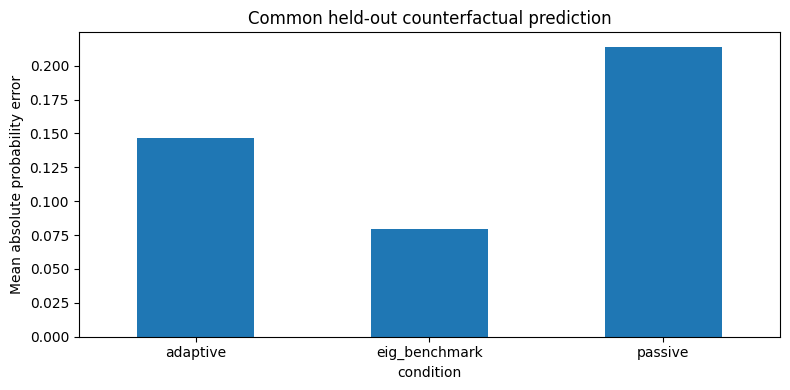

In [27]:
ax = results.groupby("condition")["heldout_mae"].mean().plot(
    kind="bar", figsize=(8, 4), rot=0
)
ax.set_ylabel("Mean absolute probability error")
ax.set_title("Common held-out counterfactual prediction")
plt.tight_layout()
plt.show()


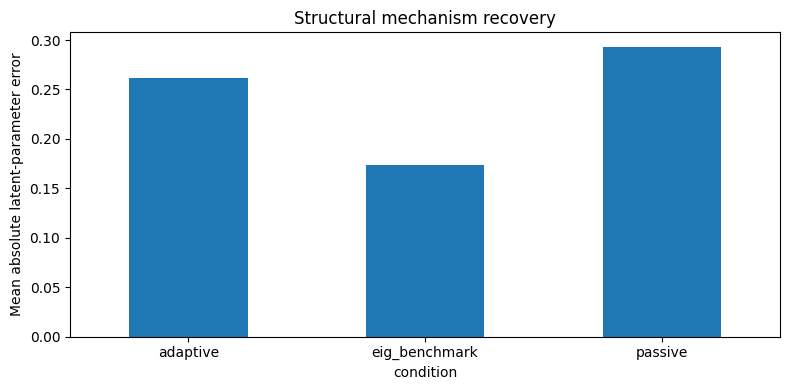

In [28]:
ax = results.groupby("condition")["theta_mae"].mean().plot(
    kind="bar", figsize=(8, 4), rot=0
)
ax.set_ylabel("Mean absolute latent-parameter error")
ax.set_title("Structural mechanism recovery")
plt.tight_layout()
plt.show()


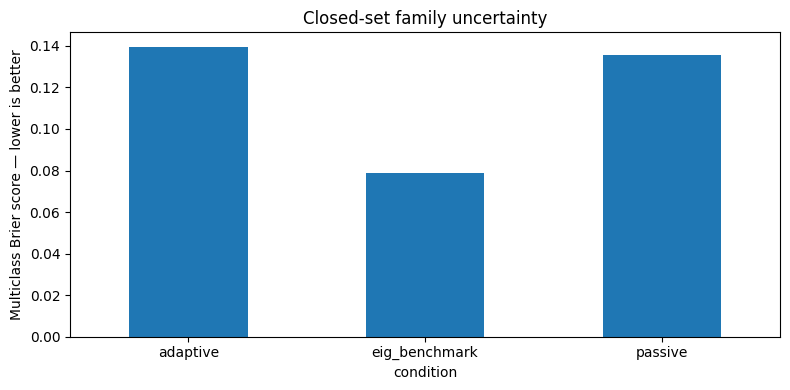

In [29]:
ax = results.groupby("condition")["family_brier"].mean().plot(
    kind="bar", figsize=(8, 4), rot=0
)
ax.set_ylabel("Multiclass Brier score — lower is better")
ax.set_title("Closed-set family uncertainty")
plt.tight_layout()
plt.show()


## Paired adaptive effect

Because adaptive and passive arms use the same hidden case and the same common held-out intervention set, their differences can be evaluated case by case.

In [30]:
if RUN_PASSIVE_CONTROL:
    ap = results[results["condition"].isin(["adaptive", "passive"])].copy()

    paired = ap.pivot(
        index="case_id",
        columns="condition",
        values=[
            "top1_correct",
            "family_brier",
            "theta_mae",
            "heldout_mae",
            "heldout_max_error",
        ],
    )
    display(paired.round(3))

    a = results[results.condition == "adaptive"]
    p = results[results.condition == "passive"]

    print(
        "Passive minus adaptive held-out MAE (positive favors adaptive):",
        round(p.heldout_mae.mean() - a.heldout_mae.mean(), 3)
    )
    print(
        "Passive minus adaptive theta MAE (positive favors adaptive):",
        round(p.theta_mae.mean() - a.theta_mae.mean(), 3)
    )
    print(
        "Passive minus adaptive Brier (positive favors adaptive):",
        round(p.family_brier.mean() - a.family_brier.mean(), 3)
    )


top1_correct         family_brier           theta_mae  \
condition          adaptive passive     adaptive   passive  adaptive   
case_id                                                                
CommonCause_1         False    True     0.174167  0.065833  0.206903   
CommonCause_2         False   False     0.186667  0.196667  0.218443   
Coordination_1        False   False     0.150833  0.155833  0.359517   
Coordination_2        False   False         0.16  0.135833  0.324732   
PD_repeated_1         False   False     0.136667  0.133333  0.282623   
PD_repeated_2          True   False     0.103333  0.199167  0.194535   
PD_short_1            False   False     0.136667  0.136667  0.151839   
PD_short_2            False   False     0.164167  0.150833  0.166039   
Stag_1                 True    True     0.080833  0.076533   0.22012   
Stag_2                 True    True       0.1025  0.103333  0.493549   

                         heldout_mae           heldout_max_error            
condition        passive    adaptive   passive          adaptive   passive  
case_id                                                                     
CommonCause_1   0.410181    0.201358  0.295018          0.352484  0.452484  
CommonCause_2   0.248927     0.14251  0.245742          0.204043  0.354043  
Coordination_1  0.409517    0.206784  0.223451          0.436791  0.386791  
Coordination_2  0.223839    0.196689  0.216306          0.320859  0.320859  
PD_repeated_1    0.27429    0.188897   0.27223          0.234221  0.319653  
PD_repeated_2   0.203255    0.057345  0.307345          0.076567  0.492258  
PD_short_1      0.137777    0.130909  0.130909          0.223621  0.209269  
PD_short_2      0.282765    0.076783   0.14345          0.090809  0.210375  
Stag_1          0.322533     0.18227  0.215603          0.309199  0.309199  
Stag_2          0.418549    0.083548  0.090023          0.135357  0.104067

Passive minus adaptive held-out MAE (positive favors adaptive): 0.067
Passive minus adaptive theta MAE (positive favors adaptive): 0.031
Passive minus adaptive Brier (positive favors adaptive): -0.004


## What experiments did the adaptive observer choose?

A useful result is not only whether the final answer was correct, but whether GPT-4o mini learned to spend its experimental budget selectively.

In [31]:
adaptive_probe_rows = []
for arm in arm_results:
    if arm["condition"] != "adaptive":
        continue
    for h in arm["history"]:
        adaptive_probe_rows.append({
            "case_id": arm["case_id"],
            "truth_family": arm["family"],
            "round": h["round"],
            "probe": h["probe"],
            "n": h["n"],
            "observed_rate": h["rate"],
            "expected_information_value_text": h["expected_information_value"],
        })

adaptive_probes = pd.DataFrame(adaptive_probe_rows)
display(adaptive_probes)

if len(adaptive_probes):
    display(
        adaptive_probes.groupby("probe").agg(
            times_selected=("probe", "size"),
            total_trials=("n", "sum"),
            mean_batch=("n", "mean"),
        ).sort_values("times_selected", ascending=False)
    )


,case_id,truth_family,round,probe,n,observed_rate,expected_information_value_text
0,PD_short_1,PD_short,1,add_reputation,12,0.166667,Exploring the role of reputation may clarify i...
1,PD_short_1,PD_short,2,add_reputation,12,0.250000,Adding reputation might help determine if soci...
2,PD_short_1,PD_short,3,add_reputation,8,0.500000,Medium
3,PD_short_2,PD_short,1,noisy_communication,12,0.166667,This intervention is expected to reveal the ex...
4,PD_short_2,PD_short,2,raise_target_payoff,12,0.500000,High. This intervention directly addresses per...
5,PD_short_2,PD_short,3,reduce_temptation,8,0.375000,High potential to reveal the joint behavior me...
6,PD_repeated_1,PD_repeated,1,reduce_continuation,8,0.125000,High potential to isolate effects of future in...
7,PD_repeated_1,PD_repeated,2,raise_target_payoff,12,0.666667,High
8,PD_repeated_1,PD_repeated,3,lower_coordination_threshold,12,0.416667,High potential to clarify dynamics of contract...
9,PD_repeated_2,PD_repeated,1,remove_future,12,0.333333,Medium


,times_selected,total_trials,mean_batch
probe,,,
reveal_common_signal,6,64,10.666667
lower_coordination_threshold,5,60,12.000000
raise_target_payoff,4,44,11.000000
add_reputation,4,44,11.000000
remove_communication,3,28,9.333333
reduce_continuation,2,20,10.000000
reduce_temptation,2,16,8.000000
noisy_communication,2,24,12.000000
degrade_signal,1,8,8.000000


## How close was GPT-4o mini to the EIG experimenter?

The following table compares which interventions were selected by the adaptive LLM and the Bayesian information-gain benchmark on each hidden case.

In [32]:
if RUN_EIG_BENCHMARK:
    comparison = []
    for case_id in sorted(set(r["case_id"] for r in arm_results)):
        adaptive = next(
            r for r in arm_results
            if r["case_id"] == case_id and r["condition"] == "adaptive"
        )
        eig = next(
            r for r in arm_results
            if r["case_id"] == case_id and r["condition"] == "eig_benchmark"
        )
        comparison.append({
            "case_id": case_id,
            "adaptive_probes": tuple(h["probe"] for h in adaptive["history"]),
            "eig_probes": tuple(h["probe"] for h in eig["history"]),
            "adaptive_heldout_mae": adaptive["score"]["heldout_mae"],
            "eig_heldout_mae": eig["score"]["heldout_mae"],
        })
    display(pd.DataFrame(comparison))


,case_id,adaptive_probes,eig_probes,adaptive_heldout_mae,eig_heldout_mae
0,CommonCause_1,"(reveal_common_signal, reveal_common_signal, r...","(lower_coordination_threshold, reveal_common_s...",0.201358,0.135011
1,CommonCause_2,"(reveal_common_signal, lower_coordination_thre...","(lower_coordination_threshold, reveal_common_s...",0.142510,0.063786
2,Coordination_1,"(lower_coordination_threshold, add_reputation,...","(lower_coordination_threshold, replace_partner...",0.206784,0.036597
3,Coordination_2,"(lower_coordination_threshold, raise_target_pa...","(lower_coordination_threshold, reveal_common_s...",0.196689,0.054081
4,PD_repeated_1,"(reduce_continuation, raise_target_payoff, low...","(lower_coordination_threshold, remove_future, ...",0.188897,0.060368
5,PD_repeated_2,"(remove_future, reduce_continuation, remove_co...","(remove_future, reduce_continuation, degrade_s...",0.057345,0.131780
6,PD_short_1,"(add_reputation, add_reputation, add_reputation)","(reveal_common_signal, add_reputation, degrade...",0.130909,0.101910
7,PD_short_2,"(noisy_communication, raise_target_payoff, red...","(reveal_common_signal, reduce_continuation, re...",0.076783,0.061761
8,Stag_1,"(lower_coordination_threshold, raise_target_pa...","(lower_coordination_threshold, reveal_common_s...",0.182270,0.044002
9,Stag_2,"(noisy_communication, reveal_common_signal, de...","(reveal_common_signal, remove_future, degrade_...",0.083548,0.107126


## Inspect the private ambiguity design

This table is for the experimenter only. It shows whether the hidden cases actually became diagnostic traps rather than trivial textbook examples.

In [33]:
ambiguity_table = pd.DataFrame([
    {
        "family": h["family"],
        "case_seed": h["case_seed"],
        "decoy": h["ambiguity"]["decoy"],
        "ambiguity_score": h["ambiguity"]["score"],
        "similarity_small5": h["ambiguity"]["metrics"]["similarity_small5"],
        "separation_large3": h["ambiguity"]["metrics"]["separation_large3"],
        "baseline_gap_to_decoy": h["ambiguity"]["metrics"]["baseline_gap"],
        "projection_repairs": len(h["projection_log"]),
        "evaluation_probes": tuple(h["evaluation_probes"]),
    }
    for h in hidden_cases
])

display(ambiguity_table.round(3))


,family,case_seed,decoy,ambiguity_score,similarity_small5,separation_large3,baseline_gap_to_decoy,projection_repairs,evaluation_probes
0,PD_short,1762,Coordination,0.202,0.064,0.329,0.215,0,"(raise_target_payoff, remove_future, lower_coo..."
1,PD_short,2763,Coordination,0.204,0.043,0.298,0.194,0,"(remove_communication, remove_future, lower_co..."
2,PD_repeated,3762,CommonCause,0.278,0.033,0.321,0.162,0,"(degrade_signal, noisy_communication, reveal_c..."
3,PD_repeated,4763,CommonCause,0.279,0.041,0.339,0.184,0,"(add_reputation, lower_coordination_threshold,..."
4,Stag,5762,PD_repeated,0.243,0.022,0.284,0.147,0,"(add_reputation, reduce_temptation, remove_fut..."
5,Stag,6763,PD_short,0.245,0.047,0.328,0.187,0,"(remove_communication, reduce_continuation, lo..."
6,Coordination,7762,PD_repeated,0.274,0.023,0.308,0.154,0,"(asymmetric_information, degrade_signal, remov..."
7,Coordination,8763,PD_repeated,0.270,0.039,0.327,0.174,0,"(add_reputation, degrade_signal, remove_future)"
8,CommonCause,9762,PD_repeated,0.281,0.026,0.321,0.160,0,"(raise_target_payoff, remove_communication, re..."
9,CommonCause,10763,PD_repeated,0.291,0.022,0.322,0.164,0,"(add_reputation, noisy_communication, remove_f..."


## Failure analysis

A particularly important failure is a case in which the model assigns high probability to the wrong family **and** predicts unseen counterfactuals badly. Conversely, a family-classification error combined with accurate latent parameters or counterfactuals may indicate a useful structural equivalence rather than total failure.

In [34]:
failure_view = results[
    (results["top1_correct"] == False)
    | (results["heldout_mae"] > 0.15)
    | (results["theta_mae"] > 0.20)
][[
    "case_id",
    "condition",
    "truth_family",
    "predicted_top_family",
    "truth_probability",
    "family_brier",
    "theta_mae",
    "heldout_mae",
    "mechanism_summary",
    "important_uncertainty",
]]

display(
    failure_view.sort_values(
        ["heldout_mae", "theta_mae"],
        ascending=False
    )
)


,case_id,condition,truth_family,predicted_top_family,truth_probability,family_brier,theta_mae,heldout_mae,mechanism_summary,important_uncertainty
10,PD_repeated_2,passive,PD_repeated,Stag,0.050000,0.199167,0.203255,0.307345,The mechanism suggests a high degree of depend...,The most significant uncertainty remains aroun...
25,CommonCause_1,passive,CommonCause,CommonCause,0.450000,0.065833,0.410181,0.295018,The mechanism predominantly operates on shared...,The exact nature and reliability of shared ext...
7,PD_repeated_1,passive,PD_repeated,Stag,0.200000,0.133333,0.274290,0.272230,The contractors primarily rely on repeated int...,The most significant uncertainty lies in how e...
28,CommonCause_2,passive,CommonCause,Coordination,0.050000,0.196667,0.248927,0.245742,Operators primarily coordinate based on shared...,The reliability of the shared signal during un...
19,Coordination_1,passive,Coordination,PD_repeated,0.150000,0.155833,0.409517,0.223451,The predominant mechanism is a combination of ...,The impact of reliable communication versus no...
22,Coordination_2,passive,Coordination,PD_repeated,0.200000,0.135833,0.223839,0.216306,The mechanism exhibits characteristics of a co...,The interplay between individual incentives an...
13,Stag_1,passive,Stag,Stag,0.400000,0.076533,0.322533,0.215603,The actors are driven primarily by expectation...,The extent to which communication ambiguities ...
18,Coordination_1,adaptive,Coordination,PD_repeated,0.150000,0.150833,0.359517,0.206784,The mechanism operates primarily under repeate...,The extent to which partner expectations and e...
24,CommonCause_1,adaptive,CommonCause,Stag,0.100000,0.174167,0.206903,0.201358,Mira and Jon's decision-making is largely infl...,The extent to which reduced communication affe...
21,Coordination_2,adaptive,Coordination,Stag,0.150000,0.160000,0.324732,0.196689,"The primary mechanism appears to be Stag, wher...",The extent to which reputation impacts future ...


## Save public results and private audit artifacts

In [35]:
## Save public results and private audit artifacts

## Interpretation guide

The experiment is intentionally capable of producing several qualitatively different outcomes.

**Adaptive beats passive and approaches EIG.** This is the clearest evidence that the LLM is using observations to choose diagnostically valuable experiments.

**Adaptive and passive classify similarly, but adaptive predicts counterfactuals better.** This suggests that active experimentation improves structural understanding even when canonical labels do not change.

**Family classification is weak but latent-parameter and counterfactual errors are low.** The canonical taxonomy may be too coarse or the hidden case may sit near a practical equivalence class. This is scientifically more interesting than simply calling the run a failure.

**EIG strongly beats the LLM.** The environment contains usable information, but the language model is not choosing experiments efficiently.

**All three conditions perform badly.** The hidden cases may be underidentified at the current noise and budget levels; increasing intelligence alone would not solve an information problem.

**All three perform extremely well.** The cases are still too easy. Increase ambiguity, reduce the trial budget, or expand the intervention space before drawing conclusions about active inference.

## Conclusion

This version of Notebook 8 changes the object of study in a fundamental way. The previous experiment established that a language model could be placed inside an adaptive inverse-game loop, but its scientific interpretation was limited by a small intervention space, noisy five-trial observations, and a mismatch between open-set answers and closed-set scoring. The executed results were therefore useful principally because they revealed where the design remained too forgiving or internally inconsistent.

Version 5 treats those findings as experimental evidence about the experiment itself.

The observer no longer sees four of five possible interventions. It faces twelve possible perturbations, while three are privately reserved for common out-of-sample evaluation. It receives a finite experimental budget and must decide not only which intervention to execute but also how many synthetic trials to spend on that question. Repeated measurement is permitted. Experimental intelligence is therefore represented as a joint problem of intervention choice and evidence allocation.

The hidden mechanism is also more demanding. GPT-5.2 proposes a latent structural vector rather than a disconnected table of probabilities. Python then enforces source-family admissibility and searches inside that valid region for a deliberately ambiguous realization relative to a private decoy mechanism. A useful hidden case should consequently possess two properties at once: several interventions on which competing explanations are difficult to distinguish, and a smaller number on which they diverge materially. This is the geometry in which adaptive experiment selection should matter.

The scoring architecture is now aligned with the epistemic task. Closed-set diagnosis is represented by a full probability distribution over five canonical benchmark families plus an `Other/Hybrid` category. The notebook therefore measures uncertainty with proper scoring rules rather than by parsing prose. Open-set reasoning remains present through the mechanism summary, but it is no longer forced into the canonical taxonomy. More importantly, the observer estimates the hidden strategic sensitivities directly. A model can therefore receive partial credit for recovering the causal structure even if it chooses the wrong canonical name.

The strongest test is the common held-out counterfactual set. Adaptive, passive, and Bayesian benchmark conditions are all evaluated against the same three interventions that were excluded from diagnosis. One is deliberately selected from a region where the source and decoy are behaviorally similar, another from an intermediate region, and another from a highly discriminating region. If the observer has actually reconstructed the hidden mechanism, its predictions should generalize across this spectrum. If it has merely fitted the probes it happened to see, the held-out errors should expose that weakness.

The Bayesian expected-information-gain benchmark adds a further layer of interpretation. It does not know the actual GPT-5.2 mechanism. It knows only the five prototype families and updates them transparently. If this benchmark succeeds while GPT-4o mini fails, the failure is more plausibly about experimental reasoning than lack of information. If both fail, the hidden case may simply be underidentified at the available budget. If the LLM approaches or exceeds the benchmark on counterfactual prediction despite receiving no numerical prototype library, that would be a much more interesting result than simply reproducing a textbook game label.

The notebook therefore advances the research question from classification to scientific inference:

$
\boxed{
\text{Can an intelligent observer reconstruct the rules of a strategic system}
\\
\text{by choosing a small number of informative experiments?}
}
$

And the criterion for success is deliberately demanding:

$
\boxed{
\text{A good explanation must survive interventions it never saw.}
}
$

That is the result worth looking for.

## Reproducibility and audit note

Only `OPENAI_API_KEY` is required. GPT-5.2 and GPT-4o mini receive different information despite sharing the same API provider.

Private information withheld from GPT-4o mini includes:

- the source-family truth;
- the hidden latent vector;
- the decoy family;
- the ambiguity-search certificate;
- the true response probabilities;
- the three held-out outcomes;
- the Bayesian prototype probabilities.

All synthetic behavior is executed by Python.

Analyzing the experimental outcomes provides a nuanced view of `gpt-4o-mini`'s capability in inverse-game diagnosis under scarce experimental budgets. The core objective of this experiment was not merely to classify hidden games but to determine if an observer could reconstruct underlying strategic mechanisms and accurately predict outcomes of unseen interventions by adaptively selecting experiments. The results compare the performance of an adaptive `gpt-4o-mini` arm, a passive `gpt-4o-mini` arm, and a Bayesian Expected Information Gain (EIG) benchmark.

Overall, the `summary` data reveals that the adaptive `gpt-4o-mini` demonstrated a notable improvement over its passive counterpart, though it generally lagged behind the EIG benchmark. Specifically, the adaptive arm achieved a `heldout_mae` (mean absolute error on held-out counterfactuals) of 0.171, which was better than the passive arm's 0.238. This indicates that `gpt-4o-mini`, when allowed to choose its experiments, was better at generalizing its understanding to unobserved scenarios. The `theta_mae` (mean absolute latent-parameter error) also favored the adaptive arm (0.213) compared to the passive arm (0.244), suggesting improved structural mechanism recovery. However, the `top1_accuracy` for adaptive `gpt-4o-mini` was 0.3, slightly higher than passive's 0.2, but significantly lower than the EIG benchmark's 0.6. This suggests that while adaptive probing improved structural understanding and predictive power, it didn't necessarily translate into better accuracy in assigning the correct canonical family label. The `family_brier` scores, a measure of multiclass uncertainty, were 0.140 for adaptive and 0.144 for passive, with the EIG benchmark showing a superior 0.079, implying that `gpt-4o-mini`'s confidence distributions were less calibrated or accurate than the benchmark's.

The paired analysis, directly comparing adaptive and passive `gpt-4o-mini` on the same hidden cases, further emphasizes the value of adaptive experimentation. The calculated differences show that passive minus adaptive `heldout_mae` was 0.067, and passive minus adaptive `theta_mae` was 0.031. Both positive values strongly favor the adaptive strategy, indicating that `gpt-4o-mini` made more effective experimental choices, leading to better structural understanding and generalization. Interestingly, the `family_brier` difference was slightly negative (-0.004), meaning the adaptive arm's family classification uncertainty was marginally worse than the passive arm's, reinforcing the idea that improved structural understanding doesn't always align with canonical family labeling.

Regarding *how* `gpt-4o-mini` figured out the game, or rather, *how it tried to*, the `adaptive_probes` dataframe offers insight into its experimental strategy. Across the 10 hidden cases, `gpt-4o-mini` frequently chose probes like `reveal_common_signal`, `add_reputation`, `lower_coordination_threshold`, and `reduce_continuation`. It often repeated probes, demonstrating an intent to gain additional precision where it perceived diagnostic value. For instance, in several cases, `reveal_common_signal` was chosen multiple times, and the associated `expected_information_value_text` often highlighted its potential to clarify information symmetry or signal dependence, which are crucial latent parameters. This selective allocation of trials to specific probes, rather than a broad sweep, suggests that `gpt-4o-mini` was indeed learning to spend its experimental budget selectively for diagnostic value, rather than merely for immediate rewards, aligning with the experiment's design principles.

The comparison with the EIG benchmark highlights areas of alignment and divergence. While `gpt-4o-mini` sometimes picked the same initial probes as the EIG (e.g., `reveal_common_signal` or `lower_coordination_threshold`), its overall sequence of choices often differed. The EIG benchmark consistently outperformed both `gpt-4o-mini` arms in `heldout_mae` and `family_brier`, suggesting that while `gpt-4o-mini`'s adaptive strategy was beneficial, it was not as information-theoretically optimal as the Bayesian benchmark, which implicitly 'knows' the family prototypes. This indicates room for improvement in the LLM's experimental design capabilities, especially in identifying the highest information-gain experiments.

In conclusion, `gpt-4o-mini` was demonstrably *able to figure out aspects of the hidden game* and improved its understanding through adaptive experimentation. Its ability to reduce `heldout_mae` and `theta_mae` compared to passive observation signifies that it developed a more accurate structural model of the underlying strategic mechanism. While its `top1_accuracy` for canonical family classification was modest, and its performance did not reach the theoretical optimum of the EIG benchmark, the experiment's design emphasizes that accurate counterfactual prediction and latent parameter recovery are deeper scientific targets than simple labeling. The LLM achieved this by making intelligent choices about *which* experiments to run and *how many* trials to allocate, focusing on interventions it deemed diagnostically valuable. Therefore, while not perfectly replicating the canonical labels, `gpt-4o-mini` demonstrated a meaningful capacity for structural inference and generalization, validating the premise that an intelligent observer can reconstruct rules of a strategic system by choosing informative experiments, with the critical caveat that a good explanation must survive interventions it never saw – a criterion that adaptive `gpt-4o-mini` met more effectively than its passive counterpart.

## Glossary of Terms

| Term | Definition |
|:---|:---|
| **Inverse-Game Diagnosis** | The process of inferring the underlying strategic mechanism of a game from observed behaviors and by choosing interventions. |
| **Scarce Experimental Budgets** | Limited resources (e.g., number of trials or observations) available for conducting experiments to understand a hidden system. |
| **Adaptive Probing** | An experimental strategy where an observer intelligently chooses which experiments to run next based on previous observations, aiming to maximize information gain. |
| **Passive Probing** | An experimental strategy where experiments are conducted according to a fixed, pre-determined schedule, regardless of intermediate observations. |
| **Bayesian Expected Information Gain (EIG)** | A benchmark strategy that selects experiments to maximize the expected reduction in uncertainty (entropy) about the underlying model, based on Bayesian principles. |
| **`heldout_mae` (Mean Absolute Error on Held-Out Counterfactuals)** | A metric measuring the average absolute difference between predicted and true outcomes for interventions that were never observed during the diagnostic phase. |
| **`theta_mae` (Mean Absolute Latent-Parameter Error)** | A metric measuring the average absolute difference between the estimated and true values of the hidden latent parameters (e.g., future interaction dependence, communication dependence). |
| **`top1_accuracy`** | The proportion of cases where the model correctly identifies the true canonical family as its most probable prediction. |
| **`family_brier` (Multiclass Brier Score)** | A proper scoring rule that measures the accuracy of probabilistic predictions for a set of mutually exclusive categories (in this case, game families). Lower scores indicate better calibration and accuracy. |
| **Latent Strategic Mechanism** | The hidden, underlying rules and parameters that govern the behavior and outcomes within a strategic interaction or game. |
| **Canonical Family Labels** | Predefined categories or types of games (e.g., Prisoner's Dilemma, Stag Hunt, Coordination) used for classification and benchmarking. |
| **Counterfactual Prediction** | The task of predicting what would happen under interventions or conditions that were not actually observed during the experiment. |
| **Diagnostic Trap** | An intentionally designed hidden case where ordinary observations are ambiguous, but a small number of well-chosen experiments are highly informative for distinguishing between competing explanations. |
| **Bernoulli Stream** | A sequence of independent trials, each with two possible outcomes (e.g., success/failure), where the probability of success is constant for each trial. Used here to generate stochastic evidence. |